# Bitcoin: predicting tomorrow's 24 hourly price changes
### Version 2: only 2018–2026 data, with fixed train / validation / test blocks

This notebook repeats the work of `bitcoin-models-new-data.ipynb` (version 1) with two changes:

1. **Only data from 2018 onwards is used.** The years 2012–2017 belong to a very different, much smaller market (illiquid hours, 2–3× larger moves, the 2017 bubble). The hypothesis is that these years may hinder the models.
2. **New groups: train / validation / test as three consecutive calendar blocks.** The training and test windows of the data-preparation step are joined into one timeline and split again:

| Block | Period (date of the predicted day) | Role |
|---|---|---|
| **Train** | Jan 2018 → Dec 2022 (5 years) | fit the models |
| **Validation** | Jan 2023 → Jun 2024 (1.5 years) | choose hyperparameters |
| **Test** | Jul 2024 → Oct 2026 (≈2.25 years) | final, one-time evaluation |

Everything else (features, metrics, models, grids) is kept from version 1 so the two versions can be compared. Each section explains what changed and why.

**Structure**

1. Load the data and keep 2018–2026.
2. Decisions taken from the checks.
3. Model inputs: scale-free features and the three blocks.
4. Metrics.
5. Validation method.
6. Baselines.
7. Models and hyperparameters: Ridge, Lasso, k-Nearest Neighbors, Random Forest, Gradient Boosting, small MLP.
8. Experiment: does removing 2012–2017 actually help?
9. Final comparison on the test period.
10. Better targets: next-day total return, next-day direction, next-day volatility.
11. Conclusions.
12. Ideas and suggestions.

All models are standard scikit-learn models: we only choose their hyperparameters.

## 1. Load the data and keep 2018–2026

In [1]:
import time, warnings
from sklearn.model_selection import PredefinedSplit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import binomtest, spearmanr

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              HistGradientBoostingRegressor, HistGradientBoostingClassifier)
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import ParameterGrid, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, accuracy_score,
                             balanced_accuracy_score, roc_auc_score, log_loss)
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message=".*Trying to unpickle.*")
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")
RANDOM_STATE = 42

data = np.load("data/btc_hourly_windows.npz")
X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]
dates_train = pd.to_datetime(data["dates_train"])
dates_test = pd.to_datetime(data["dates_test"])
feature_cols = list(data["feature_cols"])

scaler = joblib.load("data/scaler.joblib")      # StandardScaler fitted by the data-preparation step
SC_MEAN, SC_SCALE = scaler.mean_, scaler.scale_
INPUT_HOURS, TARGET_HOURS = X_train.shape[1], y_train.shape[1]

print("X_train", X_train.shape, " y_train", y_train.shape, f" {dates_train[0]} -> {dates_train[-1]}")
print("X_test ", X_test.shape,  " y_test ", y_test.shape,  f" {dates_test[0]} -> {dates_test[-1]}")
print("features:", feature_cols)

X_train (103356, 168, 6)  y_train (103356, 24)  2012-01-09 00:00:00 -> 2023-10-24 11:00:00
X_test  (25839, 168, 6)  y_test  (25839, 24)  2023-10-24 12:00:00 -> 2026-10-05 02:00:00
features: [np.str_('Open'), np.str_('High'), np.str_('Low'), np.str_('Close'), np.str_('Volume'), np.str_('Return')]


### What the files contain

- `X_*`: windows of 168 hours × 6 columns, **standardized** with the `StandardScaler` in `scaler.joblib`.
- `y_*`: 24 values per window, **not scaled**. `y[i, h]` is the simple return of hour *h* of the next day: `Close[h] / Close[h-1] − 1`. A value of 0.004 means +0.4%.
- `dates_*`: the timestamp of the **last** of the 24 target hours.

The data-preparation step already split the windows into "train" (up to Oct 2023) and "test" (Oct 2023 → Oct 2026). Here we need a different split, so we **join both arrays into one timeline** and split it again ourselves (section 3). The files themselves are not changed: this is only a model-side re-arrangement.

The next cell verifies the facts above, checks that the two arrays join without a gap, and shows how the years differ.

y_train[i] == Return of the hours after window i: True
Last training target is inside the inputs of test window 23: True -> the first test targets overlap the last training targets

Scaled Close  train: -0.72 to 3.81   test: 1.13 to 7.60


,mean_abs_return_%,share_zero_hours,up_day
year,,,
2012,0.583,0.478,0.528
2013,0.920,0.052,0.636
2014,0.568,0.009,0.468
2015,0.421,0.022,0.499
2016,0.281,0.014,0.587
2017,0.707,0.003,0.619
2018,0.576,0.002,0.510
2019,0.412,0.000,0.512
2020,0.435,0.001,0.582


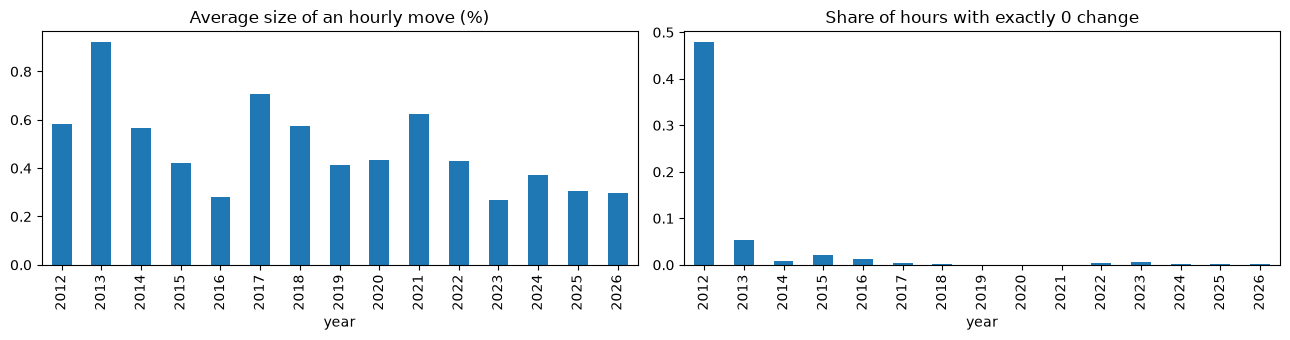


Test starts 1 hour after train ends: True
Window 0 of test = window -1 of train moved by 1 hour: True


In [2]:
ret_idx, close_idx = feature_cols.index("Return"), feature_cols.index("Close")

def unscale(X, j):
    # undo the StandardScaler for column j
    return X[..., j].astype(np.float64) * SC_SCALE[j] + SC_MEAN[j]

# 1) y[i] is exactly the "Return" column 24 windows later (windows move 1 hour at a time)
r_tr = unscale(X_train[24:2024], ret_idx)
print("y_train[i] == Return of the hours after window i:",
      np.allclose(y_train[:2000], r_tr[:, -24:], atol=1e-6))

# 2) overlap between the end of train and the start of test
r_te = unscale(X_test[:30], ret_idx)
print("Last training target is inside the inputs of test window 23:",
      np.allclose(y_train[-1], r_te[23, -24:], atol=1e-6),
      "-> the first test targets overlap the last training targets")

# 3) Scaled prices: train vs test
c_tr, c_te = X_train[::24, :, close_idx], X_test[::24, :, close_idx]
print(f"\nScaled Close  train: {c_tr.min():.2f} to {c_tr.max():.2f}   test: {c_te.min():.2f} to {c_te.max():.2f}")

# 4) Behaviour of the target by year (one non-overlapping day per window, stride 24)
all_y = np.concatenate([y_train[::24], y_test[::24]])
all_d = np.concatenate([dates_train[::24], dates_test[::24]])
yearly = pd.DataFrame({
    "year": pd.DatetimeIndex(all_d).year,
    "mean_abs_return_%": np.abs(all_y).mean(axis=1) * 100,
    "share_zero_hours": (all_y == 0).mean(axis=1),
    "up_day": (np.prod(1 + all_y, axis=1) > 1),
}).groupby("year").mean()
display(yearly.round(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
yearly["mean_abs_return_%"].plot.bar(ax=ax[0], title="Average size of an hourly move (%)")
yearly["share_zero_hours"].plot.bar(ax=ax[1], title="Share of hours with exactly 0 change")
plt.tight_layout(); plt.show()

# 5) The test array continues the training array exactly, so they can be joined into one timeline
print("\nTest starts 1 hour after train ends:", dates_test[0] - dates_train[-1] == pd.Timedelta(hours=1))
print("Window 0 of test = window -1 of train moved by 1 hour:",
      np.allclose(X_train[-1, 1:], X_test[0, :-1]))

## 2. Decisions taken from the checks

**a) Prices are standardized, but still not usable directly.** (Same as version 1.) A single global mean and standard deviation do not remove the trend: the scaled Close of the recent years lies above anything seen earlier. Tree models cannot predict outside their training range and linear models would extrapolate the price level in a meaningless way. **Decision:** undo the scaling with the scaler's `mean_` and `scale_` and build *scale-free* features (returns, ratios, volatility).

**b) Only 2018–2026 is used (new).** The table above shows why the early years are suspicious: in 2012 about half of the hours have exactly 0 change (no trading, price carried forward), 2012–2013 hourly moves are 2–3× larger than today, and 2017 was a bubble year (+1,300%) with 62% up days. A model trained on these years may learn patterns of a market that no longer exists. **Decision:** keep only windows whose *whole input week* lies in 2018 or later. Version 1 already started training in 2017, so the change in the training data is "drop 2017", but the main change is the new split (decision d). Section 8 checks whether dropping the early years really helps, using only the validation block.

**c) Volatility changes a lot between periods.** (Same as version 1.) Errors are always also reported *relative to a baseline* (the skill metrics in section 4), because raw errors of a calm and a wild period cannot be compared.

**d) Three consecutive blocks with a purge gap (new).** The joined timeline is split by date into train (2018 → 2022), validation (2023 → Jun 2024) and test (Jul 2024 → Oct 2026). Each window covers 192 hours (168 input + 24 target). Windows of the earlier block that end less than 192 hours before the next block starts are dropped ("purging"), so **no hour appears in two blocks**. This loses 8 days per border and removes any overlap leakage.
- *Why these dates?* Calendar years are easy to explain. Train keeps 5 full years with both bull and bear markets (2018 crash, 2020–2021 bull, 2022 crash). Validation (1.5 years) is long enough to judge hyperparameters. Test (≈2.25 years, ≈820 independent days) is long enough for a meaningful significance test of direction accuracy.

**e) Consecutive windows are almost identical.** (Same as version 1.) For training and validation keep every 6th window (`STRIDE = 6`): ~6× faster and almost no information lost. All test windows are evaluated.

**f) Units.** Returns are multiplied by 100, so everything is in **percent** (0.4 means +0.4%).

**g) The scaler was fitted on 2012–2023 windows.** Because of the new split, the data-preparation scaler has "seen" the validation block and part of the test block. This does **not** leak information here: we only use the scaler to undo the scaling exactly (decision a), and every feature is computed from the original, unscaled values. Whatever period it was fitted on, the features are the same.

## 3. Model inputs: scale-free features and the three blocks

Each window is turned into 42 numbers. All of them mean the same thing in 2017 and in 2026, which is what makes it possible to learn from the past and apply it to the present.

| Group | Features | Idea |
|---|---|---|
| Recent returns | 24 hourly returns, lag 1 (most recent) to lag 24 | short-term momentum or reversal |
| Return statistics | mean and standard deviation of returns over 24h, 72h, 168h | trend and volatility at three time scales |
| Price position | 24h return, 7-day return, position of the last close in the week's high–low range, distance to the week's average close | where the price stands relative to its recent past |
| Intra-hour range | average (High − Low) / Close over 24h and 168h | another volatility measure |
| Volume | log volume of last 24h vs. the week, last hour vs. the week | unusual activity |
| Calendar | hour of day and day of week of the forecast start (as sine/cosine) | trading-session and weekend patterns |

Hour and weekday are encoded as sine/cosine so that 23:00 is close to 00:00 and Sunday is close to Monday.

A second, simpler option is `FEATURE_SET = "returns_only"`: just the 168 hourly returns of the week.

The features are exactly those of version 1. After building them, the cell below assigns every window to the train, validation or test block (decision d).

In [3]:
FEATURE_SET = "engineered"      # "engineered" or "returns_only"
STRIDE = 6                      # keep every 6th training window
DATA_START = "2018-01-01"       # decision (b): first hour allowed in an input window
VAL_START  = "2023-01-01"       # decision (d): first predicted day of the validation block
TEST_START = "2024-07-01"       # decision (d): first predicted day of the test block

def window_returns(X):
    # hourly returns of the 168 input hours, in %
    return unscale(X, ret_idx) * 100

def make_features(X, dates, feature_set=FEATURE_SET):
    ret = window_returns(X)
    if feature_set == "returns_only":
        return ret, [f"ret_lag{168 - i}" for i in range(168)]
    eps = 1e-12
    close = unscale(X, feature_cols.index("Close"))
    high  = unscale(X, feature_cols.index("High"))
    low   = unscale(X, feature_cols.index("Low"))
    vol   = np.log1p(np.maximum(unscale(X, feature_cols.index("Volume")), 0))
    last = close[:, -1]

    feats, names = [ret[:, ::-1][:, :24]], [f"ret_lag{k}" for k in range(1, 25)]
    for w in (24, 72, 168):
        feats += [ret[:, -w:].mean(1, keepdims=True), ret[:, -w:].std(1, keepdims=True)]
        names += [f"ret_mean_{w}h", f"ret_std_{w}h"]
    hi, lo = high.max(1), low.min(1)
    hl = (high - low) / close * 100
    extra = {
        "ret_24h": (last / close[:, -25] - 1) * 100,
        "ret_7d": (last / close[:, 0] - 1) * 100,
        "pos_in_week_range": (last - lo) / (hi - lo + eps),
        "dist_to_week_mean": (last / close.mean(1) - 1) * 100,
        "hl_range_24h": hl[:, -24:].mean(1),
        "hl_range_168h": hl.mean(1),
        "volume_24h_vs_week": vol[:, -24:].mean(1) - vol.mean(1),
        "volume_last_vs_week": vol[:, -1] - vol.mean(1),
    }
    start = pd.DatetimeIndex(dates) - pd.Timedelta(hours=TARGET_HOURS - 1)   # first predicted hour
    extra["hour_sin"] = np.sin(2 * np.pi * start.hour / 24)
    extra["hour_cos"] = np.cos(2 * np.pi * start.hour / 24)
    extra["dow_sin"] = np.sin(2 * np.pi * start.dayofweek / 7)
    extra["dow_cos"] = np.cos(2 * np.pi * start.dayofweek / 7)
    feats += [np.asarray(v)[:, None] for v in extra.values()]
    names += list(extra)
    return np.hstack(feats), names


# ---- Join the two arrays into one timeline (decision d) ----
X_all = np.concatenate([X_train, X_test])
y_all = np.concatenate([y_train, y_test])
dates_all = dates_train.append(dates_test)
WINDOW = pd.Timedelta(hours=INPUT_HOURS + TARGET_HOURS)     # 192 hours from first input to last target
first_hour = dates_all - WINDOW + pd.Timedelta(hours=1)     # first input hour of each window

# a window belongs to a block if its predicted day falls inside the block;
# windows ending less than 192 hours before the next block are purged
v0, t0 = pd.Timestamp(VAL_START), pd.Timestamp(TEST_START)
in_train = (first_hour >= pd.Timestamp(DATA_START)) & (dates_all < v0 - WINDOW)
in_val = (dates_all >= v0) & (dates_all < t0 - WINDOW)
in_test = dates_all >= t0

def block(mask, stride):
    idx = np.flatnonzero(mask)[::stride]
    F, _ = make_features(X_all[idx], dates_all[idx])
    return F, y_all[idx] * 100, dates_all[idx], window_returns(X_all[idx])

Ftr, Ytr, Dtr, Rtr = block(in_train, STRIDE)
Fva, Yva, Dva, Rva = block(in_val, STRIDE)
Fte, Yte, Dte, Rte = block(in_test, 1)
_, feature_names = make_features(X_all[:1], dates_all[:1])

# train + validation together: used to refit the chosen model before the test
Ftv, Ytv = np.vstack([Ftr, Fva]), np.vstack([Ytr, Yva])

print(f"Feature set '{FEATURE_SET}': {Ftr.shape[1]} features\n")
for name, D, note in [("Train", Dtr, f"every {STRIDE}th window"), ("Validation", Dva, f"every {STRIDE}th window"),
                      ("Test", Dte, "all windows")]:
    print(f"{name:<11} {len(D):>6} samples  {D[0].date()} -> {D[-1].date()}  ({note})")
print(f"\nHours shared between blocks: train/val {max(0, (Dtr[-1] - (Dva[0] - WINDOW)) // pd.Timedelta(hours=1))}, "
      f"val/test {max(0, (Dva[-1] - (Dte[0] - WINDOW)) // pd.Timedelta(hours=1))}")

Feature set 'engineered': 42 features

Train         7241 samples  2018-01-08 -> 2022-12-23  (every 6th window)
Validation    2156 samples  2023-01-01 -> 2024-06-22  (every 6th window)
Test         19827 samples  2024-07-01 -> 2026-10-05  (all windows)

Hours shared between blocks: train/val 0, val/test 0


## 4. Metrics: what they mean and what values to expect

All values are computed on returns in **percent**. "Zero forecast" means predicting 0% change for every hour.

| Metric | What it measures | Better | Expected on this data |
|---|---|---|---|
| **MAE** | Average absolute error per predicted hour, in %. "On average we miss by x%." | lower | ≈ **0.3%** for the zero forecast on the test period (exact value in section 6) (equal to the average size of an hourly move). Good models land within ±1% of that value. |
| **RMSE** | Square root of the average squared error, in %. Punishes big misses more than MAE. | lower | ≈ **0.5%** (≈ the standard deviation of hourly returns in the test period). |
| **MAE skill** | `1 − MAE_model / MAE_zero`. Share of the zero forecast's error that the model removes. Makes periods with different volatility comparable. | higher | **0** = as good as predicting zero. Realistic: −0.02 to +0.005. Anything clearly above 0.01 would be surprising and worth double-checking for leakage. |
| **R²_oos** | `1 − SSE_model / SSE_zero`: the same idea as MAE skill but with squared errors. It is the usual "out-of-sample R²" in finance; it compares against the zero forecast instead of the test mean (which the model could not know in advance). | higher | Around **0**, often slightly negative. +0.005 is already a good result for hourly returns. |
| **IC** (information coefficient) | Correlation between predicted and actual returns. Measures whether the model ranks hours correctly, even if the size of its predictions is wrong (models usually predict tiny values). | higher | **0** = no information, constant forecasts have none. 0.02–0.05 is considered useful in finance. |
| **Hourly direction accuracy** | Share of hours where the predicted sign (up/down) is right. | higher | **≈ 50%** (coin flip). 51–52% is realistic. |
| **Daily direction accuracy** | The 24 predictions are compounded into one predicted next-day return; share of days where its sign is right. The most intuitive number for a presentation. | higher | **≈ 50%**. Evaluated on non-overlapping days with a significance test (next section). |
| **p-value (daily direction)** | Probability of getting this accuracy or better by pure luck if the true accuracy were 50%. | lower | Above 0.05 means "cannot be told apart from a coin flip". With ≈820 test days, accuracy must be above ≈ 52.9% to be significant. |
| **Daily balanced accuracy** | Average of the accuracy on up days and on down days. | higher | **0.50** for any rule that always says the same thing. |

**A trap with direction accuracy.** In the version-1 test period about 53% of the days were up days (the share for the new test period is printed in section 10.B). A model that simply always says "up" then gets ≈53% accuracy, and the binomial test even calls it "significant", although it knows nothing about individual days. This is why we also report **balanced accuracy**, which "always up" cannot fool (it scores exactly 0.50), and why every model must be compared with the "mean per hour" baseline, which behaves like "always up".

**Why several metrics?** MAE and RMSE answer "how far off are the numbers?". For returns the honest answer is "about as far off as predicting zero", because hourly moves are mostly noise. IC and direction accuracy answer a different question, "does the model know which way things go?", which can be slightly positive even when MAE does not improve.

**Why we pick hyperparameters by MAE.** MAE is robust to the huge outlier hours in crypto, unlike RMSE. The skill and IC values are reported next to it to see the full picture.

In [4]:
def daily_from_hourly(y_pct):
    # compound 24 hourly % returns into one next-day % return
    return (np.prod(1 + y_pct / 100, axis=1) - 1) * 100

def safe_corr(a, b):
    a, b = np.ravel(a), np.ravel(b)
    return np.nan if np.std(a) < 1e-12 else np.corrcoef(a, b)[0, 1]

def metrics(y_true, y_pred):
    nz = y_true != 0
    mae, mae0 = mean_absolute_error(y_true, y_pred), np.abs(y_true).mean()
    sse, sse0 = ((y_true - y_pred) ** 2).sum(), (y_true ** 2).sum()
    d_true, d_pred = daily_from_hourly(y_true), daily_from_hourly(y_pred)
    return {
        "MAE": mae,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE_skill": 1 - mae / mae0,
        "R2_oos": 1 - sse / sse0,
        "IC": safe_corr(y_pred, y_true),
        "HourDirAcc": ((y_pred[nz] > 0) == (y_true[nz] > 0)).mean(),
        "DayDirAcc": ((d_pred > 0) == (d_true > 0)).mean(),
    }

## 5. Validation method

The data is a time series, so the evaluation must respect time: a model may only learn from the past and be judged on the future. The process has three layers.

**Layer 1: a fixed validation block for choosing hyperparameters.**
Each hyperparameter setting is trained on the train block (2018 → 2022) and scored on the validation block (2023 → Jun 2024). The setting with the best **validation MAE skill** wins.

- *What changed from version 1?* Version 1 used walk-forward cross-validation with 4 folds inside the training period. Here the validation period is a separate, fixed block, as requested. This is simpler and every model is chosen on the same, most recent pre-test period.
- *The price of a single block.* One period can be unusual (2023 was a calm year, early 2024 a strong rally). To see how stable a result is, the validation block is cut into **3 consecutive half-years**. The skill is computed on each part, and `val_skill_std` reports their standard deviation. A difference between two settings smaller than this value is not meaningful.
- *Why still MAE skill and not plain MAE?* Same reason as before: it makes calm and volatile periods comparable. With one block it matters less for choosing, but it keeps the numbers readable ("0 = as good as predicting zero").
- *Why not a random K-fold?* It would mix past and future and put overlapping windows on both sides, which gives far too optimistic scores.

**Layer 2: the test block (Jul 2024 → Oct 2026), used once per model.**
After choosing the hyperparameters, the model is **refitted on train + validation** (2018 → Jun 2024) and evaluated once on the test block. Refitting uses the most recent 1.5 years too, which would be a waste to leave out. The test block is never used to make choices.

**Layer 3: a significance check for direction.**
As in version 1: one window per day (every 24th, ≈820 independent test days) and a binomial test against 50%, plus balanced accuracy.

The next cell shows the three blocks and how volatile each one is (the MAE of the zero forecast = the average size of an hourly move).

,from,to,samples,independent_days,zero_forecast_MAE_%,up_days
Train,2018-01-08,2022-12-23,7241,1810,0.495,0.513
Validation,2023-01-01,2024-06-22,2156,539,0.301,0.529
Test,2024-07-01,2026-10-05,19827,826,0.320,0.518


Validation part 1: 2023-01-01 -> 2023-06-29  (719 samples)
Validation part 2: 2023-06-29 -> 2023-12-26  (719 samples)
Validation part 3: 2023-12-26 -> 2024-06-22  (718 samples)


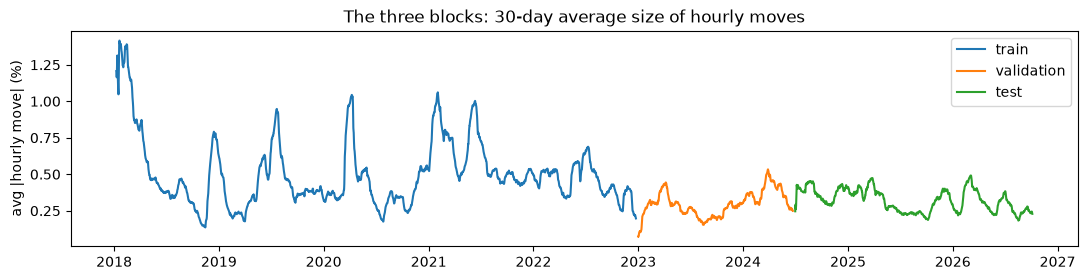

In [5]:
blocks = pd.DataFrame({
    "from": [Dtr[0].date(), Dva[0].date(), Dte[0].date()],
    "to": [Dtr[-1].date(), Dva[-1].date(), Dte[-1].date()],
    "samples": [len(Ytr), len(Yva), len(Yte)],
    "independent_days": [len(Ytr) * STRIDE // 24, len(Yva) * STRIDE // 24, len(Yte) // 24],
    "zero_forecast_MAE_%": [np.abs(Ytr).mean(), np.abs(Yva).mean(), np.abs(Yte).mean()],
    "up_days": [(daily_from_hourly(Y) > 0).mean() for Y in (Ytr, Yva, Yte)],
}, index=["Train", "Validation", "Test"])
display(blocks.round(3))

VAL_PARTS = np.array_split(np.arange(len(Yva)), 3)     # 3 consecutive half-years of the validation block
for k, p in enumerate(VAL_PARTS, 1):
    print(f"Validation part {k}: {Dva[p[0]].date()} -> {Dva[p[-1]].date()}  ({len(p)} samples)")

plt.figure(figsize=(13, 2.8))
for (name, D, Y), c in zip([("train", Dtr, Ytr), ("validation", Dva, Yva), ("test", Dte[::STRIDE], Yte[::STRIDE])],
                           ["C0", "C1", "C2"]):
    plt.plot(D, pd.Series(np.abs(Y).mean(1)).rolling(30 * 24 // STRIDE, min_periods=1).mean(), c, label=name)
plt.ylabel("avg |hourly move| (%)"); plt.title("The three blocks: 30-day average size of hourly moves")
plt.legend(); plt.show()

In [6]:
results, test_preds = [], {}

def val_tune(make_model, grid, verbose=True):
    # Train on the train block, score on the validation block: one row per setting, best first
    rows = []
    grid = list(ParameterGrid(grid))
    for n, params in enumerate(grid, 1):
        t0 = time.time()
        m = make_model(**params).fit(Ftr, Ytr)
        pred_va = m.predict(Fva)
        va = metrics(Yva, pred_va)
        parts = [metrics(Yva[p], pred_va[p])["MAE_skill"] for p in VAL_PARTS]
        rows.append({**params,
                     "train_skill": metrics(Ytr, m.predict(Ftr))["MAE_skill"],
                     "val_skill": va["MAE_skill"], "val_skill_std": np.std(parts, ddof=1),
                     "val_MAE": va["MAE"], "val_IC": va["IC"], "val_DayDirAcc": va["DayDirAcc"],
                     "seconds": round(time.time() - t0, 1)})
        print(f"  [{n}/{len(grid)}] {params}  val_skill={va['MAE_skill']:+.4f}", end="\r")
    print()
    out = pd.DataFrame(rows).sort_values("val_skill", ascending=False).reset_index(drop=True)
    if verbose:
        display(out.round(4))
    return out

def best_params(table, keys):
    # Turn the best row of a val_tune table back into clean Python values
    p = {}
    for k in keys:
        v = table.loc[0, k]
        if isinstance(v, (float, np.floating)) and float(v).is_integer():
            v = int(v)
        elif isinstance(v, np.generic):
            v = v.item()
        p[k] = v
    return p

def final_report(name, model=None, pred=None):
    # Refit on train + validation, evaluate once on the test period
    if pred is None:
        model.fit(Ftv, Ytv)
        pred = model.predict(Fte)
    m = metrics(Yte, pred)
    days = np.arange(0, len(Yte), 24)              # one window per day -> independent days
    hits = ((daily_from_hourly(pred[days]) > 0) == (daily_from_hourly(Yte[days]) > 0))
    m["DayDirAcc_indep"] = hits.mean()
    m["DayBalAcc_indep"] = balanced_accuracy_score(daily_from_hourly(Yte[days]) > 0,
                                                   daily_from_hourly(pred[days]) > 0)
    m["p_value"] = binomtest(int(hits.sum()), len(hits), 0.5, alternative="greater").pvalue
    results.append({"Model": name, **m})
    test_preds[name] = pred
    print(f"{name:<34} MAE={m['MAE']:.4f}  skill={m['MAE_skill']:+.4f}  R2oos={m['R2_oos']:+.4f}  "
          f"IC={m['IC']:+.3f}  HourDir={m['HourDirAcc']:.3f}  DayDir={m['DayDirAcc_indep']:.3f} (p={m['p_value']:.2f})  "
          f"DayBalAcc={m['DayBalAcc_indep']:.3f}")
    return model

## 6. Baselines

A model is only interesting if it beats simple rules that need no learning:

- **Zero**: predict 0% change for every hour. For a random walk this is the best possible forecast, which is why it is the reference for MAE skill and R²_oos. (For direction it counts as always "not up".)
- **Mean per hour**: the average return of each of the 24 future hours over train + validation. Since Bitcoin went up over time this is slightly positive, so for direction it means "always up".
- **Persistence**: tomorrow's 24 hours repeat today's 24 hours.
- **Reversal of the last hour**: only the first hour is forecast, as −0.05 × the last observed return, a small bet on mean reversion.

In [7]:
final_report("Baseline: zero", pred=np.zeros_like(Yte))
final_report("Baseline: mean per hour", pred=np.tile(Ytv.mean(0), (len(Yte), 1)))
final_report("Baseline: persistence", pred=Rte[:, -24:])
rev = np.zeros_like(Yte); rev[:, 0] = -0.05 * Rte[:, -1]
final_report("Baseline: last-hour reversal", pred=rev);

Baseline: zero                     MAE=0.3196  skill=+0.0000  R2oos=+0.0000  IC=+nan  HourDir=0.496  DayDir=0.496 (p=0.61)  DayBalAcc=0.500
Baseline: mean per hour            MAE=0.3197  skill=-0.0003  R2oos=-0.0003  IC=-0.000  HourDir=0.503  DayDir=0.504 (p=0.42)  DayBalAcc=0.500
Baseline: persistence              MAE=0.4740  skill=-0.4832  R2oos=-1.0185  IC=-0.009  HourDir=0.496  DayDir=0.492 (p=0.69)  DayBalAcc=0.492


Baseline: last-hour reversal       MAE=0.3195  skill=+0.0001  R2oos=-0.0001  IC=+0.002  HourDir=0.497  DayDir=0.526 (p=0.07)  DayBalAcc=0.526


## 7. Models and hyperparameters

Each model follows the same steps: (1) train on the train block and score a small grid on the validation block, (2) look at train vs. validation error to spot over- or underfitting, (3) retrain the best setting on train + validation and evaluate it once on the test period.

**How to read the CV tables.**
- `train_skill` (on the train block) clearly above 0 while `val_skill` is below 0 means **overfitting**: the model learned patterns of the training period that do not repeat.
- Both close to 0 means the model is (correctly) cautious and stays near the zero forecast.
- `val_skill_std` is the standard deviation of the skill over the 3 half-years of the validation block: it shows how much the result changes from one period to another. A difference between two settings smaller than this value is not meaningful.
- `val_MAE`, `val_IC` and `val_DayDirAcc` are shown for information. Hyperparameters are chosen by `val_skill`.

**General rule:** if the best value sits at the edge of the grid, extend the grid in that direction and run again. In this version the first runs put several best values on an edge (Ridge, Lasso, KNN, Random Forest, Gradient Boosting, MLP, and some models of section 10), so those grids were extended. The extended values are marked in the tables below.

### 7.1 Ridge regression

Linear regression with an L2 penalty on the coefficients. One model predicts all 24 hours. Features are standardized inside the pipeline (the scaler is refitted on each fold's training part only, so there is no leakage).

| Hyperparameter | Effect | Grid |
|---|---|---|
| `alpha` | Penalty strength. Small: the model follows the training data closely (overfits). Large: coefficients shrink to 0 and the model becomes the "mean per hour" baseline. | 0.1 → 1,000,000,000 (log scale; extended after the first run) |

  [11/11] {'alpha': 1000000000}  val_skill=-0.0013


,alpha,train_skill,val_skill,val_skill_std,val_MAE,val_IC,val_DayDirAcc,seconds
0,1.000000e+09,0.0000,-0.0013,0.0005,0.3013,-0.0139,0.5292,0.0
1,1.000000e+08,0.0000,-0.0013,0.0005,0.3013,-0.0139,0.5292,0.0
2,1.000000e+07,0.0000,-0.0013,0.0005,0.3013,-0.0138,0.5292,0.0
3,1.000000e+06,0.0001,-0.0013,0.0005,0.3014,-0.0130,0.5292,0.0
4,1.000000e+05,0.0009,-0.0016,0.0002,0.3014,-0.0044,0.5325,0.0
5,1.000000e+04,0.0027,-0.0055,0.0019,0.3026,0.0150,0.5107,0.0
6,1.000000e+03,0.0004,-0.0162,0.0047,0.3058,0.0206,0.5032,0.0
7,1.000000e+02,-0.0014,-0.0207,0.0056,0.3072,0.0209,0.5070,0.0
8,1.000000e+01,-0.0019,-0.0218,0.0059,0.3075,0.0208,0.4986,0.1
9,1.000000e+00,-0.0023,-0.0224,0.0062,0.3077,0.0207,0.4981,0.1


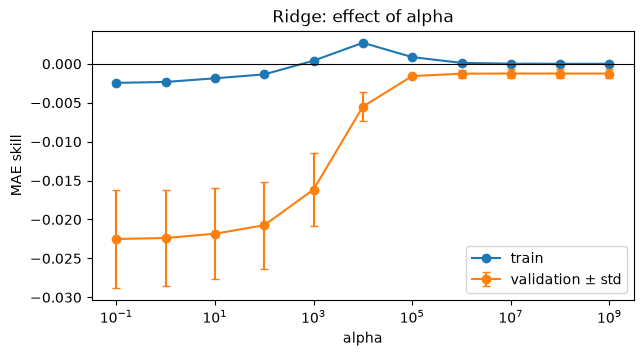

Ridge {'alpha': 1000000000}        MAE=0.3197  skill=-0.0003  R2oos=-0.0003  IC=-0.000  HourDir=0.503  DayDir=0.504 (p=0.42)  DayBalAcc=0.500


In [8]:
make_ridge = lambda alpha: make_pipeline(StandardScaler(), Ridge(alpha=alpha))
ridge_cv = val_tune(make_ridge, {"alpha": [0.1, 1, 10, 100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000, 1_000_000_000]})

t = ridge_cv.sort_values("alpha")
plt.figure(figsize=(7, 3.5))
plt.semilogx(t["alpha"], t["train_skill"], "o-", label="train")
plt.errorbar(t["alpha"], t["val_skill"], yerr=t["val_skill_std"], fmt="o-", capsize=3, label="validation ± std")
plt.axhline(0, color="k", lw=0.8)
plt.xlabel("alpha"); plt.ylabel("MAE skill"); plt.title("Ridge: effect of alpha"); plt.legend(); plt.show()

p_ridge = best_params(ridge_cv, ["alpha"])
ridge_model = final_report(f"Ridge {p_ridge}", make_ridge(**p_ridge))

### 7.2 Lasso regression

Like Ridge but with an L1 penalty, which sets some coefficients exactly to 0. It doubles as **feature selection**: the features it keeps are the ones with the most linear signal. If it removes everything, that tells you it found nothing better than the average.

| Hyperparameter | Effect | Grid |
|---|---|---|
| `alpha` | Penalty strength; larger means fewer features kept | 0.003 → 1 (extended after the first run) |

In [9]:
make_lasso = lambda alpha: make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=5000))
lasso_cv = val_tune(make_lasso, {"alpha": [0.003, 0.01, 0.03, 0.1, 0.3, 1.0]})
p_lasso = best_params(lasso_cv, ["alpha"])
lasso_model = final_report(f"Lasso {p_lasso}", make_lasso(**p_lasso))

coef = pd.DataFrame(lasso_model[-1].coef_.T, index=feature_names)        # features x 24 hours
kept = coef.abs().sum(axis=1)
print(f"\nLasso keeps {(kept > 0).sum()} of {len(kept)} features (non-zero for at least one hour).")
if (kept > 0).any():
    print("Strongest kept features:", list(kept[kept > 0].sort_values(ascending=False).head(8).index))
else:
    print("Lasso removed every feature: the best it found is to predict the average return for each hour.")

  [6/6] {'alpha': 1.0}  val_skill=-0.0013


,alpha,train_skill,val_skill,val_skill_std,val_MAE,val_IC,val_DayDirAcc,seconds
0,0.300,0.0000,-0.0013,0.0005,0.3013,-0.0139,0.5292,0.0
1,0.100,0.0000,-0.0013,0.0005,0.3013,-0.0139,0.5292,0.0
2,1.000,0.0000,-0.0013,0.0005,0.3013,-0.0139,0.5292,0.0
3,0.030,0.0011,-0.0027,0.0007,0.3018,0.0040,0.5306,0.0
4,0.010,0.0017,-0.0089,0.0016,0.3037,0.0147,0.5107,0.1
5,0.003,0.0002,-0.0160,0.0043,0.3058,0.0196,0.4977,0.2


Lasso {'alpha': 0.3}               MAE=0.3197  skill=-0.0003  R2oos=-0.0003  IC=-0.000  HourDir=0.503  DayDir=0.504 (p=0.42)  DayBalAcc=0.500

Lasso keeps 0 of 42 features (non-zero for at least one hour).
Lasso removed every feature: the best it found is to predict the average return for each hour.


### 7.3 k-Nearest Neighbors

Finds the *k* past weeks most similar to the current one and averages what happened the day after: "history rhymes". It has no real training phase, so it is very easy to explain. Scaling matters because it is distance-based.

| Hyperparameter | Effect | Grid |
|---|---|---|
| `n_neighbors` | Few neighbours: noisy forecasts. Many: smooth, close to the average. (Must stay below the number of training samples.) | 10, 50, 200, 500, 1000, 2000, 4000, 6000 (extended after the first runs) |
| `weights` | `uniform`: all neighbours count equally. `distance`: closer ones count more. | both |

Note: with `weights="distance"` the train MAE is ≈ 0, because every training point is its own nearest neighbour. Only the validation MAE is meaningful there.

In [10]:
make_knn = lambda n_neighbors, weights: make_pipeline(
    StandardScaler(), KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights))
knn_cv = val_tune(make_knn, {"n_neighbors": [10, 50, 200, 500, 1000, 2000, 4000, 6000], "weights": ["uniform", "distance"]})
p_knn = best_params(knn_cv, ["n_neighbors", "weights"])
knn_model = final_report(f"KNN {p_knn}", make_knn(**p_knn))

  [16/16] {'n_neighbors': 6000, 'weights': 'distance'}  val_skill=-0.0010


,n_neighbors,weights,train_skill,val_skill,val_skill_std,val_MAE,val_IC,val_DayDirAcc,seconds
0,4000,distance,1.0000,-0.0007,0.0001,0.3012,-0.0045,0.5186,6.2
1,4000,uniform,0.0003,-0.0007,0.0001,0.3012,-0.0061,0.5204,3.0
2,2000,distance,1.0000,-0.0009,0.0003,0.3012,0.0092,0.4852,3.1
3,2000,uniform,0.0006,-0.0009,0.0003,0.3012,0.0089,0.4935,1.7
4,6000,distance,1.0000,-0.0010,0.0001,0.3013,-0.0097,0.5292,8.7
5,6000,uniform,0.0001,-0.0011,0.0002,0.3013,-0.0111,0.5292,4.3
6,1000,uniform,0.0010,-0.0016,0.0006,0.3014,0.0083,0.4833,1.0
7,1000,distance,1.0000,-0.0016,0.0006,0.3014,0.0083,0.4833,1.6
8,500,distance,1.0000,-0.0032,0.0016,0.3019,0.0055,0.4847,0.8
9,500,uniform,0.0015,-0.0032,0.0016,0.3019,0.0051,0.4861,0.6


KNN {'n_neighbors': 4000, 'weights': 'distance'} MAE=0.3197  skill=-0.0003  R2oos=-0.0003  IC=+0.000  HourDir=0.501  DayDir=0.509 (p=0.31)  DayBalAcc=0.505


### 7.4 Random Forest

An average of many decision trees, each trained on a random sample of the data and of the features. It captures non-linear effects (for example "after a big drop in a calm week…") and predicts the 24 hours together. No scaling needed.

| Hyperparameter | Effect | Grid |
|---|---|---|
| `max_depth` | How many questions each tree may ask. The main overfitting control. | 2, 4, 8, 16 (extended) |
| `min_samples_leaf` | Minimum number of samples per final leaf. Larger values give smoother, more cautious forecasts. | 20, 100, 300 (extended) |
| `max_features` | Share of features considered at each split. Lower values give more varied trees (and faster training). | 0.3, 0.6 |
| `n_estimators` | Number of trees. More trees means more stable results, never more overfitting, only slower. | 50 for tuning (to save time), 300 for the final model |

  [24/24] {'max_depth': 16, 'max_features': 0.6, 'min_samples_leaf': 300}  val_skill=-0.0017


,max_depth,max_features,min_samples_leaf,train_skill,val_skill,val_skill_std,val_MAE,val_IC,val_DayDirAcc,seconds
0,4,0.3,300,0.0016,-0.0012,0.0005,0.3013,-0.0046,0.5250,0.2
1,4,0.3,100,0.0018,-0.0013,0.0004,0.3013,-0.0013,0.5269,0.3
2,4,0.6,20,0.0018,-0.0013,0.0003,0.3013,-0.0043,0.5278,0.4
3,8,0.3,100,0.0035,-0.0013,0.0005,0.3014,-0.0009,0.5241,0.4
4,2,0.3,300,0.0009,-0.0013,0.0003,0.3014,-0.0055,0.5288,0.2
5,4,0.3,20,0.0021,-0.0013,0.0003,0.3014,-0.0039,0.5274,0.3
6,2,0.6,300,0.0009,-0.0013,0.0004,0.3014,-0.0078,0.5301,0.3
7,4,0.6,300,0.0016,-0.0013,0.0004,0.3014,-0.0052,0.5213,0.4
8,2,0.6,20,0.0007,-0.0013,0.0003,0.3014,-0.0111,0.5274,0.3
9,2,0.3,100,0.0008,-0.0013,0.0002,0.3014,-0.0049,0.5274,0.2


Random Forest {'max_depth': 4, 'min_samples_leaf': 300, 'max_features': 0.3} MAE=0.3197  skill=-0.0003  R2oos=-0.0003  IC=+0.004  HourDir=0.501  DayDir=0.503 (p=0.44)  DayBalAcc=0.499


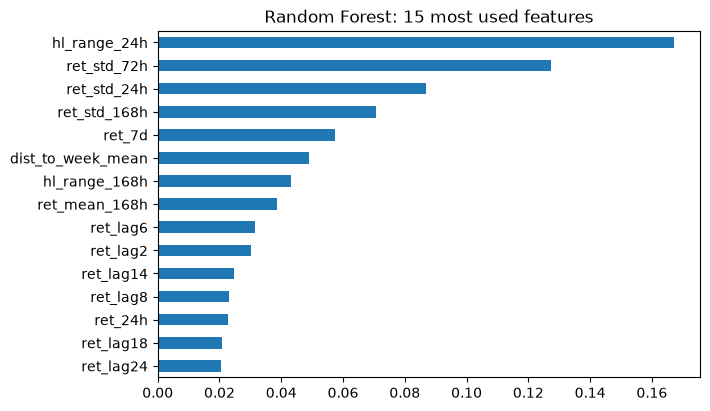

In [11]:
make_rf = lambda **p: RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=RANDOM_STATE, **p)
rf_cv = val_tune(make_rf, {"max_depth": [2, 4, 8, 16], "min_samples_leaf": [20, 100, 300], "max_features": [0.3, 0.6]})
p_rf = best_params(rf_cv, ["max_depth", "min_samples_leaf", "max_features"])
rf_model = final_report(f"Random Forest {p_rf}",
                        RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE, **p_rf))

imp = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values()
imp.tail(15).plot.barh(figsize=(7, 4.5), title="Random Forest: 15 most used features"); plt.show()

Feature importance shows which inputs the forest *uses*, not that they actually predict well. Trees also split on noise. Volatility features usually come out on top: they help the forest decide how large its forecasts should be, not which direction.

### 7.5 Gradient Boosting (HistGradientBoostingRegressor)

Trees are built one after another, each correcting the errors of the previous ones. It is usually the strongest classical model on tabular data. It predicts one target at a time, so `MultiOutputRegressor` trains 24 models (one per hour), which makes it the slowest model here, so the grid is small. `loss="absolute_error"` makes it optimise MAE directly, which is robust to extreme hours.

| Hyperparameter | Effect | Grid |
|---|---|---|
| `learning_rate` | How strongly each new tree corrects. Smaller is more cautious and needs more trees. | 0.01, 0.03, 0.1 (extended) |
| `max_depth` | Complexity of each tree (1 = a single split per tree) | 1, 2, 4 (extended) |
| `max_iter` + `early_stopping` | Maximum number of trees. Training stops early when an internal validation score stops improving. | 200 |
| `min_samples_leaf` | Smoothness, as in the Random Forest | 200 |

In [12]:
make_hgb = lambda **p: MultiOutputRegressor(HistGradientBoostingRegressor(
    loss="absolute_error", max_iter=200, min_samples_leaf=200, early_stopping=True,
    random_state=RANDOM_STATE, **p))
hgb_cv = val_tune(make_hgb, {"learning_rate": [0.01, 0.03, 0.1], "max_depth": [1, 2, 4]})
p_hgb = best_params(hgb_cv, ["learning_rate", "max_depth"])
hgb_model = final_report(f"Gradient Boosting {p_hgb}", make_hgb(**p_hgb))

  [9/9] {'learning_rate': 0.1, 'max_depth': 4}  val_skill=-0.0021


,learning_rate,max_depth,train_skill,val_skill,val_skill_std,val_MAE,val_IC,val_DayDirAcc,seconds
0,0.03,1,0.0025,-0.0000,0.0004,0.3010,0.0137,0.5311,1.3
1,0.10,1,0.0040,-0.0002,0.0003,0.3010,0.0150,0.5297,1.1
2,0.01,2,0.0020,-0.0002,0.0003,0.3010,0.0116,0.5292,1.3
3,0.01,1,0.0015,-0.0002,0.0003,0.3010,0.0142,0.5297,1.5
4,0.01,4,0.0042,-0.0003,0.0003,0.3011,0.0144,0.5292,1.7
5,0.03,2,0.0039,-0.0003,0.0002,0.3011,0.0145,0.5311,1.3
6,0.03,4,0.0080,-0.0006,0.0007,0.3011,0.0168,0.5264,1.4
7,0.10,2,0.0080,-0.0006,0.0006,0.3012,0.0136,0.5288,1.1
8,0.10,4,0.0175,-0.0021,0.0009,0.3016,0.0153,0.5158,1.3


Gradient Boosting {'learning_rate': 0.03, 'max_depth': 1} MAE=0.3196  skill=-0.0002  R2oos=-0.0007  IC=+0.005  HourDir=0.505  DayDir=0.505 (p=0.39)  DayBalAcc=0.501


### 7.6 (Optional) small MLP from scikit-learn

A small ready-made feed-forward network: we only choose its size and penalty and do not build anything ourselves. Check with your teacher whether it fits the course rules, and skip it if not.

| Hyperparameter | Effect | Grid |
|---|---|---|
| `hidden_layer_sizes` | Neurons per layer | (32,), (64, 32) |
| `alpha` | L2 penalty, as in Ridge | 0.01, 1, 10, 100, 300, 1000, 3000, 10000 (extended) |
| `early_stopping` | Stops when an internal validation score stops improving | on |

In [13]:
make_mlp = lambda **p: make_pipeline(StandardScaler(), MLPRegressor(
    max_iter=300, early_stopping=True, random_state=RANDOM_STATE, **p))
mlp_cv = val_tune(make_mlp, {"hidden_layer_sizes": [(32,), (64, 32)], "alpha": [0.01, 1.0, 10.0, 100.0, 300.0, 1000.0, 3000.0, 10000.0]})
p_mlp = best_params(mlp_cv, ["hidden_layer_sizes", "alpha"])
mlp_model = final_report(f"MLP {p_mlp}", make_mlp(**p_mlp))

  [16/16] {'alpha': 10000.0, 'hidden_layer_sizes': (64, 32)}  val_skill=-0.0017


,alpha,hidden_layer_sizes,train_skill,val_skill,val_skill_std,val_MAE,val_IC,val_DayDirAcc,seconds
0,1000.00,"(32,)",-0.0001,-0.0011,0.0007,0.3013,-0.0121,0.5292,0.4
1,3000.00,"(32,)",-0.0001,-0.0011,0.0008,0.3013,-0.0126,0.5292,0.4
2,10000.00,"(32,)",-0.0001,-0.0011,0.0008,0.3013,-0.0129,0.5292,0.4
3,10000.00,"(64, 32)",-0.0001,-0.0017,0.0005,0.3015,-0.0122,0.5292,0.6
4,3000.00,"(64, 32)",-0.0001,-0.0017,0.0005,0.3015,-0.0123,0.5292,0.6
5,1000.00,"(64, 32)",-0.0001,-0.0017,0.0005,0.3015,-0.0124,0.5292,0.6
6,300.00,"(64, 32)",-0.0001,-0.0017,0.0005,0.3015,-0.0121,0.5292,0.7
7,100.00,"(64, 32)",-0.0001,-0.0019,0.0005,0.3015,-0.0124,0.5292,0.7
8,100.00,"(32,)",-0.0004,-0.0034,0.0008,0.3020,0.0010,0.5283,0.3
9,300.00,"(32,)",-0.0010,-0.0036,0.0010,0.3020,-0.0015,0.4903,0.3


MLP {'hidden_layer_sizes': (32,), 'alpha': 1000} MAE=0.3197  skill=-0.0004  R2oos=-0.0004  IC=-0.000  HourDir=0.503  DayDir=0.504 (p=0.42)  DayBalAcc=0.500


## 8. Experiment: does removing 2012–2017 actually help?

This is the hypothesis behind version 2, so it should be tested, not assumed. The best Ridge and the best Random Forest from section 7 are trained on the train block **extended back** to different start years and scored on the **validation block**. Nothing else changes. The test block is not touched, so this stays an honest check.

Because the 24-hour target has almost no signal, differences there may be invisible. The same experiment is therefore also run on the **next-day volatility** target (section 10.C), where models do have skill: if old data hurts, it should show there. For volatility a Gradient Boosting model with fixed settings is used (learning rate 0.1, depth 3, leaf 20, the setting chosen in version 1) and the metric is R².

More data is usually better, but only if the old data behaves like the new data.

In [14]:
def log_realized_vol(y_pct):
    lr = np.log1p(y_pct / 100) * 100
    return np.log(np.sqrt((lr ** 2).sum(axis=1)) + 1e-6)

# every STRIDE-th window of the whole history up to the train/validation purge
hist_idx = np.flatnonzero(dates_all < v0 - WINDOW)[::STRIDE]
F_hist, _ = make_features(X_all[hist_idx], dates_all[hist_idx])
Y_hist, first_hist = y_all[hist_idx] * 100, first_hour[hist_idx]
yc_va = log_realized_vol(Yva)

rows = []
for start in ["2012-01-01", "2014-01-01", "2016-01-01", "2017-01-01", "2018-01-01", "2019-01-01", "2020-01-01"]:
    m = first_hist >= pd.Timestamp(start)
    F, Y = F_hist[m], Y_hist[m]
    ridge = make_ridge(**p_ridge).fit(F, Y)
    rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE, **p_rf).fit(F, Y)
    vol = HistGradientBoostingRegressor(learning_rate=0.1, max_depth=3, min_samples_leaf=20, early_stopping=True,
                                        random_state=RANDOM_STATE).fit(F, log_realized_vol(Y))
    rows.append({"train_from": start, "n_train": m.sum(),
                 "Ridge_val_skill": metrics(Yva, ridge.predict(Fva))["MAE_skill"],
                 "Ridge_val_IC": metrics(Yva, ridge.predict(Fva))["IC"],
                 "RF_val_skill": metrics(Yva, rf.predict(Fva))["MAE_skill"],
                 "RF_val_IC": metrics(Yva, rf.predict(Fva))["IC"],
                 "Vol_GB_val_R2": r2_score(yc_va, vol.predict(Fva)),
                 "Vol_GB_val_MAE": mean_absolute_error(yc_va, vol.predict(Fva))})
    print(f"  train from {start}: done", end="\r")
hist = pd.DataFrame(rows).set_index("train_from")
display(hist.round(4))

,n_train,Ridge_val_skill,Ridge_val_IC,RF_val_skill,RF_val_IC,Vol_GB_val_R2,Vol_GB_val_MAE
train_from,,,,,,,
2012-01-01,16008,-0.0000,-0.0165,0.0003,-0.0027,0.2928,0.3784
2014-01-01,13084,-0.0001,-0.0243,-0.0001,-0.0116,0.2442,0.3846
2016-01-01,10164,-0.0004,-0.0210,-0.0002,-0.0154,0.3585,0.3618
2017-01-01,8700,-0.0004,-0.0200,-0.0003,-0.0170,0.4062,0.3488
2018-01-01,7240,-0.0006,-0.0133,-0.0006,-0.0108,0.4085,0.3479
2019-01-01,5780,-0.0006,-0.0196,-0.0006,-0.0130,0.3713,0.3617
2020-01-01,4320,-0.0007,-0.0269,-0.0009,-0.0200,0.4224,0.3481


## 9. Final comparison on the test period (Jul 2024 → Oct 2026)

`DayDirAcc_indep` and `p_value` come from the ≈820 non-overlapping test days (layer 3 of the validation).

,MAE,RMSE,MAE_skill,R2_oos,IC,HourDirAcc,DayDirAcc_indep,p_value,DayBalAcc_indep
Model,,,,,,,,,
Baseline: last-hour reversal,0.3195,0.4929,0.0001,-0.0001,0.0020,0.4969,0.5260,0.0721,0.5258
Baseline: zero,0.3196,0.4929,0.0000,0.0000,NaN,0.4959,0.4958,0.6096,0.5000
"Gradient Boosting {'learning_rate': 0.03, 'max_depth': 1}",0.3196,0.4931,-0.0002,-0.0007,0.0050,0.5052,0.5054,0.3904,0.5012
"KNN {'n_neighbors': 4000, 'weights': 'distance'}",0.3197,0.4930,-0.0003,-0.0003,0.0004,0.5014,0.5091,0.3132,0.5050
"Random Forest {'max_depth': 4, 'min_samples_leaf': 300, 'max_features': 0.3}",0.3197,0.4930,-0.0003,-0.0003,0.0043,0.5011,0.5030,0.4447,0.4988
Ridge {'alpha': 1000000000},0.3197,0.4930,-0.0003,-0.0003,-0.0000,0.5028,0.5042,0.4174,0.5000
Lasso {'alpha': 0.3},0.3197,0.4930,-0.0003,-0.0003,-0.0000,0.5028,0.5042,0.4174,0.5000
Baseline: mean per hour,0.3197,0.4930,-0.0003,-0.0003,-0.0000,0.5028,0.5042,0.4174,0.5000
"MLP {'hidden_layer_sizes': (32,), 'alpha': 1000}",0.3197,0.4930,-0.0004,-0.0004,-0.0000,0.5028,0.5042,0.4174,0.5000


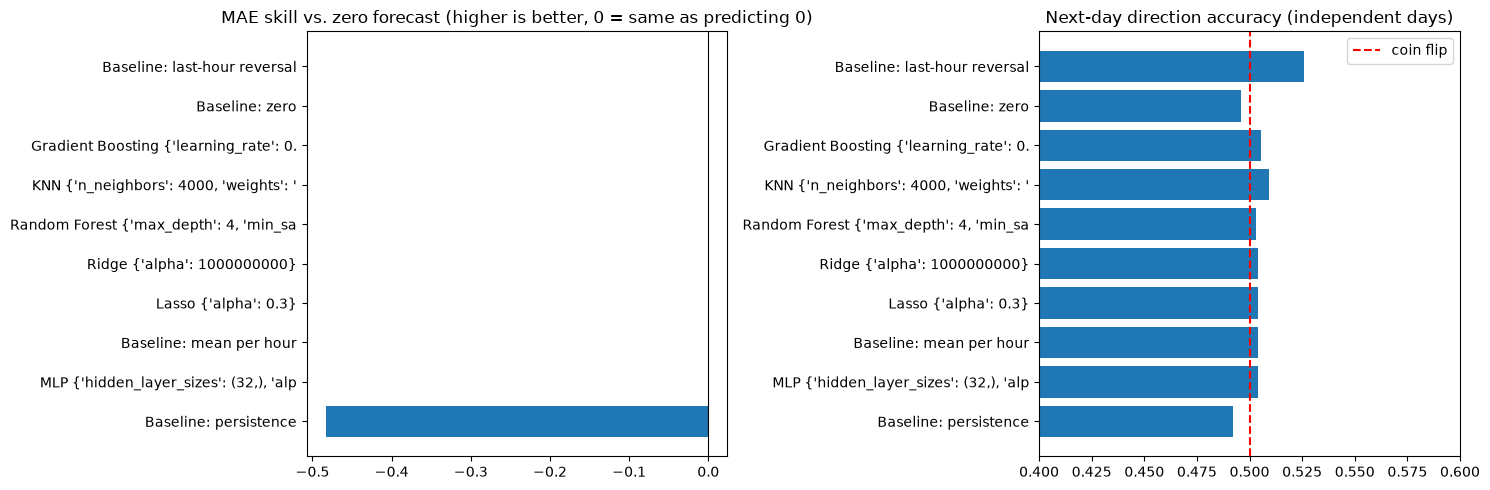

In [15]:
summary = pd.DataFrame(results).drop_duplicates("Model", keep="last").set_index("Model")
cols = ["MAE", "RMSE", "MAE_skill", "R2_oos", "IC", "HourDirAcc", "DayDirAcc_indep", "p_value", "DayBalAcc_indep"]
display(summary[cols].sort_values("MAE").round(4))

s = summary.sort_values("MAE_skill")
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].barh(s.index.str.slice(0, 38), s["MAE_skill"]); ax[0].axvline(0, color="k", lw=0.8)
ax[0].set_title("MAE skill vs. zero forecast (higher is better, 0 = same as predicting 0)")
ax[1].barh(s.index.str.slice(0, 38), s["DayDirAcc_indep"]); ax[1].axvline(0.5, color="red", ls="--", label="coin flip")
ax[1].set_xlim(0.4, 0.6); ax[1].set_title("Next-day direction accuracy (independent days)"); ax[1].legend()
plt.tight_layout(); plt.show()

**Error by forecast horizon.** Is the first hour (closest to the data) more predictable than hour 24? The plot shows the MAE skill for each of the 24 predicted hours.

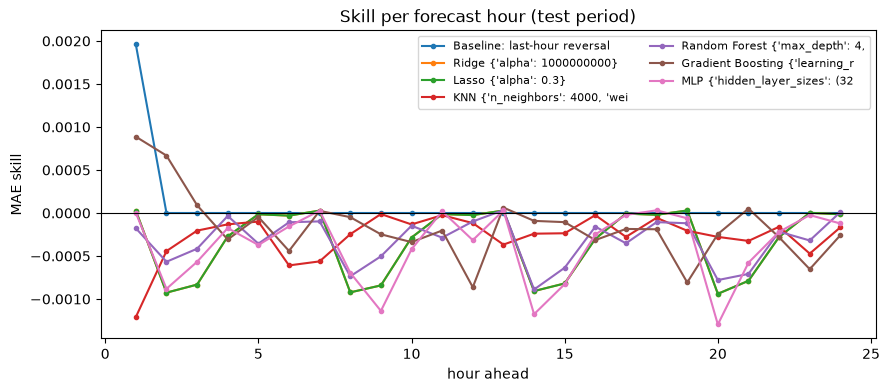

In [16]:
plt.figure(figsize=(10, 4))
mae0_h = np.abs(Yte).mean(axis=0)
for name, pred in test_preds.items():
    if name.startswith("Baseline") and "reversal" not in name:
        continue
    plt.plot(range(1, 25), 1 - np.abs(Yte - pred).mean(axis=0) / mae0_h, marker=".", label=name[:30])
plt.axhline(0, color="k", lw=0.8)
plt.xlabel("hour ahead"); plt.ylabel("MAE skill"); plt.title("Skill per forecast hour (test period)")
plt.legend(fontsize=8, ncol=2); plt.show()

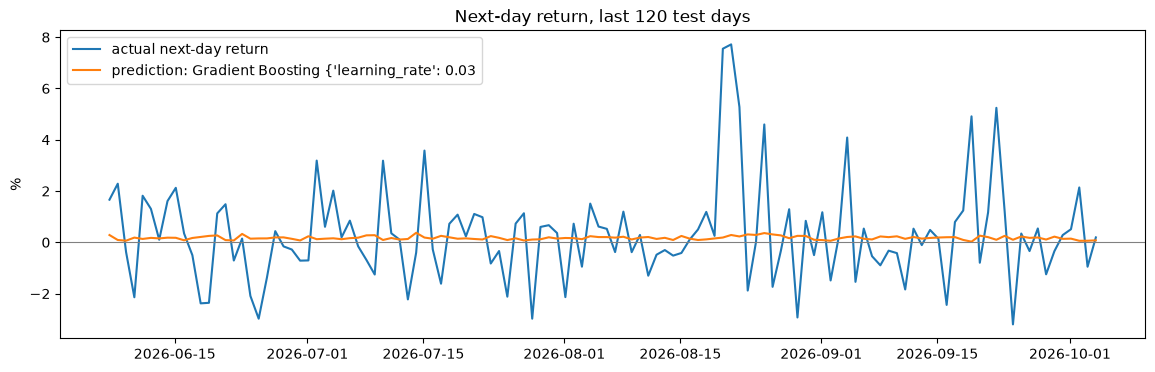

In [17]:
# Predicted vs. actual next-day return over the last 120 test days, for the best model by MAE skill
best_name = summary.drop([i for i in summary.index if i.startswith("Baseline")])["MAE_skill"].idxmax()
days = np.arange(len(Yte) - 120 * 24, len(Yte), 24)
plt.figure(figsize=(14, 4))
plt.plot(Dte[days], daily_from_hourly(Yte[days]), label="actual next-day return")
plt.plot(Dte[days], daily_from_hourly(test_preds[best_name][days]), label=f"prediction: {best_name[:40]}")
plt.axhline(0, color="grey", lw=0.8); plt.ylabel("%"); plt.legend()
plt.title("Next-day return, last 120 test days"); plt.show()

The prediction line is almost flat compared to reality. This is not a bug: when a model cannot tell what will happen, the forecast that minimises the error is a value close to zero. The models "know that they don't know".

## 10. Better targets

The 24-hour target has three weaknesses:

1. **It is almost pure noise.** Each hourly move is tiny compared to its randomness, so every model collapses towards zero and the comparison between models becomes hard to see.
2. **24 outputs are expensive.** Gradient Boosting has to train 24 models, and the 24 errors are summed even though users mostly care about the day as a whole.
3. **Simple returns are not additive.** +10% then −10% is not 0%. Log returns `ln(1 + r)` fix this: the daily log return is simply the sum of the 24 hourly log returns.

All the alternatives below are built from the **same** `y` arrays, so the data preparation does not need to change.

| Alternative target | Type | Why it can be better | What to expect |
|---|---|---|---|
| **A. Next-day log return** = Σ ln(1 + r_h) | regression, 1 value | Same information as the 24 values for anyone who cares about the day. 24× cheaper to train, simpler to explain. Additive. | Still mostly noise: skill ≈ 0, R²_oos ≈ 0 |
| **B. Next-day direction** (up / down) | classification | Directly answers the question people ask. Lets you use classifiers and metrics like accuracy and ROC AUC, which are well covered in basic ML courses. | AUC ≈ 0.50–0.53, accuracy ≈ 50% |
| **C. Next-day volatility** = log of the realized volatility √Σ(ln(1 + r_h))² | regression, 1 value | **Volatility is predictable** (calm days follow calm days, wild days follow wild days, the so-called *volatility clustering*). Models show clear, measurable skill, so hyperparameter effects become visible. Useful in practice for risk management. | R² ≈ 0.3–0.6, clearly above the baselines |

**Recommendation.** Keep the 24-hour return target as the main task (it is the assigned problem), but add **C (volatility)** as a second experiment. It shows the methods working when there *is* signal, and contrasts it with returns, where there is none. That makes a much stronger conclusion than "nothing beats zero". Targets A and B are cheap extras that make the return results easier to present.

For these single-value targets we use scikit-learn's own `GridSearchCV` with a `PredefinedSplit`: it receives train + validation together and is told which rows are the validation block, so it does exactly the same as `val_tune` (fit on train, score on validation) with less code. After choosing, `GridSearchCV` automatically refits the best setting on train + validation, the same rule as in section 7.

In [18]:
def daily_log_return(y_pct):
    return np.log1p(y_pct / 100).sum(axis=1) * 100

test_days = np.arange(0, len(Yte), 24)      # evaluate single-value targets on independent days

# -1 = always in training, 0 = the (only) validation fold
val_split = PredefinedSplit(np.r_[np.full(len(Ytr), -1), np.zeros(len(Yva), dtype=int)])

def tune_and_test(estimator, grid, y_tv, y_te, scoring):
    gs = GridSearchCV(estimator, grid, cv=val_split, scoring=scoring, n_jobs=-1).fit(Ftv, y_tv)
    return gs.best_params_, gs.best_estimator_.predict(Fte[test_days]), gs

# next-day log return (used by targets A and B), for train + validation and for the test days
ya_tv, ya_te = daily_log_return(Ytv), daily_log_return(Yte)[test_days]
ya_tr = ya_tv[:len(Ytr)]

### 10.A Next-day log return (one value)

Metrics: MAE, MAE skill and R²_oos against the zero forecast, IC and direction accuracy, all as in section 4. Note that the numbers are now in "% per day", so the MAE is roughly 5× larger than the hourly one.

In [19]:
def report_A(name, pred):
    mae, mae0 = mean_absolute_error(ya_te, pred), np.abs(ya_te).mean()
    print(f"{name:<45} MAE={mae:.3f}  skill={1 - mae / mae0:+.4f}  "
          f"R2oos={1 - ((ya_te - pred) ** 2).sum() / (ya_te ** 2).sum():+.4f}  "
          f"IC={safe_corr(pred, ya_te):+.3f}  DirAcc={((pred > 0) == (ya_te > 0)).mean():.3f}")

report_A("Baseline: zero", np.zeros_like(ya_te))
for name, est, grid in [
    ("Ridge", make_pipeline(StandardScaler(), Ridge()), {"ridge__alpha": [1, 100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000]}),
    ("Random Forest", RandomForestRegressor(n_estimators=200, max_features=0.3, n_jobs=-1, random_state=RANDOM_STATE),
     {"max_depth": [1, 2, 3, 6, 10], "min_samples_leaf": [10, 20, 50, 200, 500]}),
    ("Gradient Boosting", HistGradientBoostingRegressor(loss="absolute_error", early_stopping=True, random_state=RANDOM_STATE),
     {"learning_rate": [0.01, 0.03, 0.1, 0.3], "max_depth": [1, 2, 4, 6], "min_samples_leaf": [30, 100, 300, 1000]}),
]:
    params, pred, _ = tune_and_test(est, grid, ya_tv, ya_te, "neg_mean_absolute_error")
    report_A(f"{name} {params}", pred)

Baseline: zero                                MAE=1.667  skill=+0.0000  R2oos=+0.0000  IC=+nan  DirAcc=0.496


Ridge {'ridge__alpha': 100000}                MAE=1.667  skill=+0.0005  R2oos=+0.0017  IC=+0.063  DirAcc=0.507


Random Forest {'max_depth': 1, 'min_samples_leaf': 200} MAE=1.667  skill=+0.0000  R2oos=+0.0009  IC=+0.023  DirAcc=0.499


Gradient Boosting {'learning_rate': 0.3, 'max_depth': 1, 'min_samples_leaf': 1000} MAE=1.681  skill=-0.0079  R2oos=-0.0077  IC=-0.002  DirAcc=0.482


### 10.B Next-day direction (classification)

Metrics for classification:

| Metric | Meaning | Expected |
|---|---|---|
| **Accuracy** | Share of days with the correct direction | ≈ 50%. Compare with "always up", which already gets the share of up days. |
| **Balanced accuracy** | Average of the accuracy on up days and on down days, so a model cannot look good by always saying "up" | 0.5 = no skill |
| **ROC AUC** | Probability that the model gives a higher "up" probability to a random up day than to a random down day | 0.5 = no skill; 0.52–0.55 would be a good result |
| **Log loss** | How good the predicted probabilities are; it punishes confident wrong answers | ln 2 ≈ 0.693 for always saying 50/50. Lower is better. |

Hyperparameters are chosen by ROC AUC, because accuracy can be "won" by always predicting the majority class.

In [20]:
yb_tv, yb_te = (ya_tv > 0).astype(int), (ya_te > 0).astype(int)
yb_tr = yb_tv[:len(Ytr)]
print(f"Share of up days: train+validation {yb_tv.mean():.3f}, test {yb_te.mean():.3f}")

def report_B(name, proba):
    pred = (proba > 0.5).astype(int)
    p = binomtest(int((pred == yb_te).sum()), len(yb_te), 0.5, alternative="greater").pvalue
    print(f"{name:<55} acc={accuracy_score(yb_te, pred):.3f} (p={p:.2f})  bal_acc={balanced_accuracy_score(yb_te, pred):.3f}  "
          f"AUC={roc_auc_score(yb_te, proba) if np.std(proba) > 0 else 0.5:.3f}  "
          f"logloss={log_loss(yb_te, np.clip(proba, 1e-6, 1 - 1e-6)):.3f}")

report_B("Baseline: always up (train+val up-share as probability)", np.full(len(yb_te), yb_tv.mean()))
for name, est, grid in [
    ("Logistic Regression", make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
     {"logisticregression__C": [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]}),
    ("Random Forest", RandomForestClassifier(n_estimators=200, max_features=0.3, n_jobs=-1, random_state=RANDOM_STATE),
     {"max_depth": [1, 2, 3, 6, 10], "min_samples_leaf": [10, 20, 50, 200, 500]}),
    ("Gradient Boosting", HistGradientBoostingClassifier(early_stopping=True, random_state=RANDOM_STATE),
     {"learning_rate": [0.01, 0.03, 0.1, 0.3], "max_depth": [1, 2, 4, 6], "min_samples_leaf": [30, 100, 300, 1000]}),
]:
    gs = GridSearchCV(est, grid, cv=val_split, scoring="roc_auc", n_jobs=-1).fit(Ftv, yb_tv)
    report_B(f"{name} {gs.best_params_}", gs.best_estimator_.predict_proba(Fte[test_days])[:, 1])

Share of up days: train+validation 0.517, test 0.504
Baseline: always up (train+val up-share as probability) acc=0.504 (p=0.42)  bal_acc=0.500  AUC=0.500  logloss=0.693


Logistic Regression {'logisticregression__C': 0.01}     acc=0.525 (p=0.08)  bal_acc=0.523  AUC=0.544  logloss=0.691


Random Forest {'max_depth': 1, 'min_samples_leaf': 500} acc=0.501 (p=0.50)  bal_acc=0.500  AUC=0.511  logloss=0.693


Gradient Boosting {'learning_rate': 0.1, 'max_depth': 1, 'min_samples_leaf': 1000} acc=0.497 (p=0.58)  bal_acc=0.495  AUC=0.504  logloss=0.695


### 10.C Next-day volatility

Target: the log of the next day's realized volatility, `ln √Σ(ln(1 + r_h))²` (in %). The log makes the distribution symmetric, so a calm day and a wild day are treated more evenly.

Baselines from volatility research: **yesterday's volatility** (persistence) and the **average over the past week**. Here the usual R² (against the test mean) is the right metric, because the question is how much of the day-to-day variation in volatility the model explains.

| Metric | Meaning | Expected |
|---|---|---|
| **MAE (log vol)** | Average error in log units; 0.3 ≈ "off by about 30%" | lower is better; baselines ≈ 0.3–0.4 |
| **R²** | Share of the variation in volatility explained | 0 = no better than a constant; 0.3–0.6 is realistic here |

In [21]:
yc_tv, yc_te = log_realized_vol(Ytv), log_realized_vol(Yte)[test_days]
lr_in = np.log1p(Rte[test_days] / 100) * 100                     # input-week log returns (%)

def report_C(name, pred):
    print(f"{name:<55} MAE={mean_absolute_error(yc_te, pred):.3f}  R2={r2_score(yc_te, pred):.3f}  "
          f"corr={safe_corr(pred, yc_te):.3f}")

report_C("Baseline: yesterday's volatility", np.log(np.sqrt((lr_in[:, -24:] ** 2).sum(1)) + 1e-6))
report_C("Baseline: average daily volatility of last week", np.log(np.sqrt((lr_in ** 2).sum(1) / 7) + 1e-6))
vol_models = {}
for name, est, grid in [
    ("Ridge", make_pipeline(StandardScaler(), Ridge()), {"ridge__alpha": [0.00001, 0.001, 0.1, 10, 1_000]}),
    ("Random Forest", RandomForestRegressor(n_estimators=200, max_features=0.3, n_jobs=-1, random_state=RANDOM_STATE),
     {"max_depth": [6, 10, 16], "min_samples_leaf": [3, 10, 50]}),
    ("Gradient Boosting", HistGradientBoostingRegressor(early_stopping=True, random_state=RANDOM_STATE),
     {"learning_rate": [0.03, 0.1, 0.3], "max_depth": [1, 2, 3, 6], "min_samples_leaf": [5, 20, 100, 300]}),
]:
    params, pred, gs = tune_and_test(est, grid, yc_tv, yc_te, "neg_mean_absolute_error")
    vol_models[name] = (gs, pred)
    report_C(f"{name} {params}", pred)

Baseline: yesterday's volatility                        MAE=0.442  R2=-0.161  corr=0.421
Baseline: average daily volatility of last week         MAE=0.380  R2=0.100  corr=0.450


Ridge {'ridge__alpha': 1e-05}                           MAE=0.332  R2=0.345  corr=0.625


Random Forest {'max_depth': 10, 'min_samples_leaf': 10} MAE=0.300  R2=0.459  corr=0.680


Gradient Boosting {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 20} MAE=0.297  R2=0.474  corr=0.690


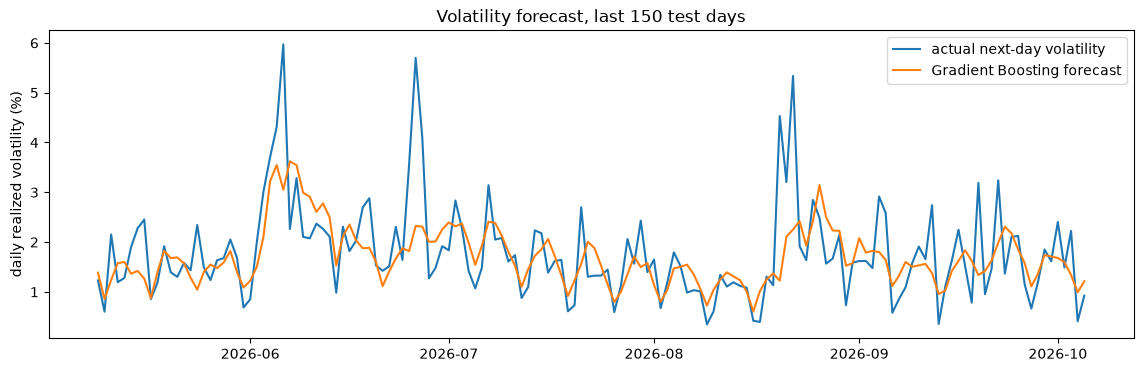

In [22]:
pred = vol_models["Gradient Boosting"][1]
last = slice(-150, None)
plt.figure(figsize=(14, 4))
plt.plot(Dte[test_days][last], np.exp(yc_te[last]), label="actual next-day volatility")
plt.plot(Dte[test_days][last], np.exp(pred[last]), label="Gradient Boosting forecast")
plt.ylabel("daily realized volatility (%)"); plt.title("Volatility forecast, last 150 test days"); plt.legend(); plt.show()

## 11. Conclusions

These conclusions come from the run on the data available on 5 October 2026 (train 2018 → Dec 2022, validation Jan 2023 → Jun 2024, test Jul 2024 → Oct 2026).

**1. The 24 hourly returns still cannot be predicted better than "zero".**
On the test block the zero forecast has an MAE of 0.3196%. Every tuned model lands at 0.3196–0.3197%: MAE skill between −0.0002 and −0.0004, IC at most 0.005. On the validation block every setting of every model has a negative skill too. Removing 2012–2017 did not change this: the result is the same as in version 1.

**2. The "always up" illusion of version 1 is gone, and nothing replaces it.** The new test block is much more balanced (50.4% up days on the independent days, against 53.5% in version 1). The models that effectively say "always up" now score 50.4% daily direction accuracy (p = 0.42). No model reaches significance (best: KNN 50.9%, p = 0.31). The best number belongs to a *baseline*: "last-hour reversal" gets 52.6% with balanced accuracy 0.526, but p = 0.07, so it is not significant either. This shows how easily a lucky period makes a simple rule look good.

**3. Hyperparameters behave exactly as in version 1: more freedom means worse validation.**
- *Ridge / Lasso:* validation skill improves as the penalty grows, until the model becomes the "mean per hour" forecast. From alpha = 10⁶ (Ridge) or 0.1 (Lasso, 0 of 42 features kept) every value gives the same result, −0.0013. The best value is at the edge of the grid even after extending it twice, but this is a **plateau**: there is nothing more to find in that direction.
- *KNN:* more neighbours is better up to k = 4000 (skill −0.0007). k = 6000 is worse again (−0.0010) because it approaches the plain average of all 7,241 training samples. This time the optimum is inside the grid.
- *Random Forest:* depth 16 with leaf 20 has train skill +0.012 but validation −0.002. The best is depth 4 with leaf 300. The differences between the shallow settings (≤ 0.0001) are far below `val_skill_std` (≈ 0.0005), so they are all equivalent.
- *Gradient Boosting:* learning rate 0.1 with depth 4 has train skill +0.018 and validation −0.002. The best uses **depth 1** (a single split per tree, the smallest possible value) with learning rate 0.03.
- *MLP:* weak penalties overfit (validation down to −0.037). From alpha = 1000 on the result does not change (plateau).

**4. Does removing 2012–2017 help? (section 8, validation block only)**
- *24-hour target:* no measurable effect. All start years give skills between −0.0009 and +0.0003, the same size as the variation between the validation half-years. With the chosen hyperparameters Ridge is just the training mean, so its column only shows how close each period's average is to the validation period's average.
- *Volatility target:* here the answer is **clearly yes for the very early years**. Training from 2012 gives R² 0.29 and from 2014 0.24, against 0.41 when starting in 2017 or 2018. The reason: volatility is a *level*, and 2012–2015 were 2–3× more volatile than today. A model trained on them expects too much volatility. Between 2017 and 2018 there is no difference (0.406 vs 0.409), and later starts (2019: 0.37, 2020: 0.42) only add noise from having less data.
- **So the hypothesis is half right.** Early years hurt as soon as a model learns something real (volatility). For returns there is nothing to learn, so the training period cannot matter.

**5. Better targets (same conclusions as version 1, slightly different numbers):**
- *Next-day log return (A):* Ridge again finds a weak signal: IC 0.063, R²_oos +0.002 (version 1: 0.094 and +0.009). The tree models find nothing. Gradient Boosting chose the most extreme corner of its grid (learning rate 0.3, depth 1, leaf 1000) and then did worse than zero on test (skill −0.008). This shows the main weakness of a *single* validation block: with ≈540 validation days the choice between settings that are all near zero is driven by noise.
- *Direction classification (B):* Logistic Regression is the best direction model of the whole notebook: accuracy 52.5%, balanced accuracy 0.523, ROC AUC 0.544, but p = 0.08, so it is still **not significant** at the 5% level. Its best C is now 0.01, inside the grid (version 1 picked the grid edge 10⁻⁶). The tree classifiers chose depth 1 and are no better than a coin.
- *Next-day volatility (C):* **the models clearly work, even a bit better than in version 1.**

| Model | MAE (log vol) | R² | Correlation |
|---|---|---|---|
| Yesterday's volatility | 0.442 | −0.16 | 0.42 |
| Last week's average volatility | 0.380 | 0.10 | 0.45 |
| Ridge | 0.332 | 0.35 | 0.63 |
| Random Forest (depth 10, leaf 10) | 0.300 | 0.46 | 0.68 |
| Gradient Boosting (lr 0.1, depth 2, leaf 20) | **0.297** | **0.47** | **0.69** |

(Ridge gives the same result for every small alpha, so its best value sitting at the grid edge does not matter.)

**6. Comparison with version 1.** The test periods are different (version 2 tests on the last 2.25 years of version 1's test period), so the numbers cannot be compared one to one. The *pattern*, however, is identical in both versions:

| | Version 1 (2017+, walk-forward CV) | Version 2 (2018+, fixed blocks) |
|---|---|---|
| 24h target, best test MAE skill | −0.0003 | −0.0002 |
| Daily direction, best tuned model | 53.4% (= always up) | 50.9% (not significant) |
| Next-day log return, Ridge IC | 0.094 | 0.063 |
| Direction classifier, best AUC | 0.540 | 0.544 |
| Volatility, Gradient Boosting R² | 0.454 | 0.474 |

**Recommended story for the project (unchanged, now with stronger support):** "Hourly price changes are essentially unpredictable with basic ML. Walk-forward validation and a separate validation block both show that more flexible models only overfit, and the choice of training years makes no difference. Aggregating to one daily value reveals a weak signal. The size of tomorrow's moves (volatility), however, is predictable: Gradient Boosting explains about 45–47% of its variation, and there the training years *do* matter: including 2012–2015 lowers R² from 0.41 to 0.24–0.29."

## 12. Ideas and suggestions

**For the models (could be done in this notebook):**

1. **Use walk-forward CV inside train + validation, keep the separate test block.** Section 10.A showed that one validation block of ≈540 days can pick an extreme setting by luck. Combining the two ideas (version 1's walk-forward folds on 2018 → Jun 2024, version 2's untouched test block) gives both stability and a clean test.
2. **Gradient Boosting's early stopping is not time-aware.** `early_stopping=True` holds out a *random* 10% of the training rows. Because consecutive windows overlap, those rows are near-copies of training rows, so training stops too late. A cleaner option is `early_stopping=False` with `max_iter` as a tuned hyperparameter.
3. **Make volatility the second main result.** It is the only target where hyperparameters change the result clearly, so it is the best place to show tuning. A natural extension is to predict a *range* for tomorrow's return with `GradientBoostingRegressor(loss="quantile", alpha=0.1 / 0.9)`, still a standard scikit-learn model.
4. **Classic volatility features (HAR model).** Volatility research uses the realized volatility of the last day, week and month as inputs to a plain linear regression. Day and week are already in the features. A month needs a longer window (see data suggestion 1).
5. **Report a confidence interval for the volatility R²** (bootstrap over the ≈820 test days), so the difference between Random Forest (0.46) and Gradient Boosting (0.47) can be judged.

**For the data preparation (suggestions for the data step only, not implemented here):**

1. **Longer or extra windows.** A 168-hour window limits the features to one week. A 30-day window, or a separate daily series, would allow monthly volatility and trend features.
2. **Store the hourly series once instead of 129,195 overlapping windows.** The windows repeat every hour 168 times (≈520 MB in memory). Building the windows inside the model notebook would make it easy to try other window lengths and splits.
3. **Scale-free inputs from the start.** The global `StandardScaler` on prices does not remove the trend, and the models undo it anyway. Log returns, or prices divided by the last close of each window, would be directly usable.
4. **Scaler fitted per split.** The scaler was fitted on all windows up to Oct 2023, which now includes the validation block. This does not matter here (the scaling is undone exactly), but anyone using the scaled values directly would leak validation information.
5. **Flag forward-filled hours.** In the early years many hours have 0 return because there was no trade. An explicit "no trade" flag (or volume = 0 check) would make this visible instead of looking like a real 0% move.